<div dir="rtl">

# 2. پاکسازی و آماد هسازی دادهها و تحلیل اکتشافی

</div>

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_csv('./covid_19.csv')
df = df.drop(columns=['id'],axis=1)

df.head()
df.shape

(566602, 22)

### Nan-values

In [158]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: [nan 'No' 'Yes']
pneumonia: ['No' 'Yes' nan]
pregnancy: [nan 'No' 'Yes']
diabetes: ['No' 'Yes' nan]
copd: ['No' 'Yes' nan]
asthma: ['No' 'Yes' nan]
inmsupr: ['No' 'Yes' nan]
hypertension: ['No' 'Yes' nan]
other_disease: ['No' 'Yes' nan]
cardiovascular: ['No' 'Yes' nan]
obesity: ['No' 'Yes' nan]
renal_chronic: ['No' 'Yes' nan]
tobacco: ['No' 'Yes' nan]
contact_other_covid: ['No' nan 'Yes']
covid_res: ['Positive' 'Negative' 'Not Yet Determined']
icu: [nan 'Not Admitted' 'Admitted']


In [159]:
df.loc[df['sex'] == 'male', 'pregnancy'] = "No"
df['pregnancy'] = df['pregnancy'].fillna('No') 

df['contact_other_covid'] = df['contact_other_covid'].fillna('Unknown')

#add died column based on date_died
df['died'] = df['date_died'].notna().astype(int)

cols = [
    'diabetes','copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity','pneumonia',
    'renal_chronic','tobacco'
]

df[cols] = df[cols].fillna('No')
df['date_died'] = df['date_died'].fillna(0)


# هر کسی که ICU Admitted بوده، قطعا بستری بوده است
df.loc[df['icu'] == 'Admitted', 'patient_type'] = 'hospitalized'
df.loc[df['intubed'] == 'Yes', 'patient_type'] = 'hospitalized'

# Outpatients: definitely not intubed or in ICU
df.loc[df['patient_type'] == 'not hospitalized', 'intubed'] = 'No'
df.loc[df['patient_type'] == 'not hospitalized', 'icu'] = 'No'

# Inpatients: treat remaining NaN as "No" (most will not be intubed/ICU)
df['icu'] = df['icu'].replace({'Admitted': 'Yes', 'Not Admitted': 'No'}).fillna('No')
df['intubed'] = df['intubed'].fillna('No')



In [160]:
df['died'].value_counts()

died
0    530426
1     36176
Name: count, dtype: int64

In [161]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: ['No' 'Yes']
pneumonia: ['No' 'Yes']
pregnancy: ['No' 'Yes']
diabetes: ['No' 'Yes']
copd: ['No' 'Yes']
asthma: ['No' 'Yes']
inmsupr: ['No' 'Yes']
hypertension: ['No' 'Yes']
other_disease: ['No' 'Yes']
cardiovascular: ['No' 'Yes']
obesity: ['No' 'Yes']
renal_chronic: ['No' 'Yes']
tobacco: ['No' 'Yes']
contact_other_covid: ['No' 'Unknown' 'Yes']
covid_res: ['Positive' 'Negative' 'Not Yet Determined']
icu: ['No' 'Yes']
died: [0 1]


In [162]:
nan_nums = df.isna().sum()
nan_percentage = (nan_nums/df.shape[0]*100).round(2)
pd.concat(
    [nan_nums, nan_percentage],
    axis=1,
    keys=['nan_numbers', 'nan_percentage']
)

,nan_numbers,nan_percentage
sex,0,0.0
patient_type,0,0.0
entry_date,0,0.0
date_symptoms,0,0.0
date_died,0,0.0
intubed,0,0.0
pneumonia,0,0.0
age,0,0.0
pregnancy,0,0.0
diabetes,0,0.0


### Encoding categorical data

In [163]:

df['sex'] = df['sex'].map({
    'male': 2,
    'female': 1
})

binary_map = {'Yes': 1, 'No': 0}
all_binary_cols = [
    'diabetes', 'copd', 'asthma', 'hypertension', 'cardiovascular', 
    'obesity', 'renal_chronic', 'inmsupr', 'other_disease', 'tobacco',
    'pneumonia', 'intubed', 'icu', 'pregnancy'
]

for col in all_binary_cols:
    df[col] = df[col].map(binary_map)

# ۳. انکودینگ سایر متغیرهای چندحالته
df['patient_type'] = df['patient_type'].map({'hospitalized': 1, 'not hospitalized': 0})
df['covid_res'] = df['covid_res'].map({'Positive': 1, 'Negative': 0, 'Not Yet Determined': 2})
df['contact_other_covid'] = df['contact_other_covid'].map({'Yes': 1, 'No': 0, 'Unknown': 2})

# ۴. تبدیل به فرمت تاریخ (جاهای خالی NaT می‌مانند که درست است)
df['date_symptoms'] = pd.to_datetime(df['date_symptoms'], dayfirst=True)
df['entry_date'] = pd.to_datetime(df['entry_date'], dayfirst=True)
df['date_died'] = pd.to_datetime(df['date_died'], dayfirst=True) 

# ۵. ساخت تایم‌استمپ‌ها
df['timestamp_entry_date'] = df['entry_date'].astype('int64') // 10**9 
df['timestamp_date_symptoms'] = df['date_symptoms'].astype('int64') // 10**9

# ۶. تبدیل به int8 برای بهینه‌سازی کامل حافظه
cat_cols = [
    'patient_type', 'intubed', 'pneumonia', 'diabetes',
    'copd', 'asthma', 'inmsupr', 'hypertension',
    'other_disease', 'cardiovascular', 'obesity',
    'renal_chronic', 'tobacco', 'contact_other_covid',
    'covid_res', 'icu', 'died', 'sex', 'pregnancy'
]
df[cat_cols] = df[cat_cols].astype('int8')

In [164]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: [2 1]
patient_type: [1 0]
intubed: [0 1]
pneumonia: [0 1]
pregnancy: [0 1]
diabetes: [0 1]
copd: [0 1]
asthma: [0 1]
inmsupr: [0 1]
hypertension: [0 1]
other_disease: [0 1]
cardiovascular: [0 1]
obesity: [0 1]
renal_chronic: [0 1]
tobacco: [0 1]
contact_other_covid: [0 2 1]
covid_res: [1 0 2]
icu: [0 1]
died: [0 1]


In [165]:
df.describe()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,died,timestamp_entry_date,timestamp_date_symptoms
count,566602.000000,566602.000000,566602,566602,566602,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,5.666020e+05,5.666020e+05
mean,1.506726,0.811427,2020-05-25 16:38:01.576132608,2020-05-22 00:39:34.695464960,1973-03-21 05:21:42.692189600,0.017587,0.155621,42.622483,0.007171,0.125010,0.016114,0.031814,0.015845,0.163268,0.030152,0.022547,0.162852,0.019855,0.084746,1.009402,0.625619,0.017847,0.063847,1.590425e+09,1.590108e+09
min,1.000000,0.000000,2020-01-01 00:00:00,2020-01-01 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.577837e+09,1.577837e+09
25%,1.000000,1.000000,2020-05-11 00:00:00,2020-05-07 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.589155e+09,1.588810e+09
50%,2.000000,1.000000,2020-05-31 00:00:00,2020-05-27 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.590883e+09,1.590538e+09
75%,2.000000,1.000000,2020-06-15 00:00:00,2020-06-11 00:00:00,1970-01-01 00:00:00,0.000000,0.000000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,1.592179e+09,1.591834e+09
max,2.000000,1.000000,2020-06-29 00:00:00,2020-06-29 00:00:00,2020-06-29 00:00:00,1.000000,1.000000,120.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.593389e+09,1.593389e+09
std,0.499955,0.391170,NaN,NaN,NaN,0.131446,0.362496,16.659973,0.084377,0.330731,0.125913,0.175505,0.124877,0.369610,0.171005,0.148453,0.369230,0.139503,0.278503,0.779960,0.685858,0.132394,0.244481,2.156197e+06,2.163914e+06


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   sex                      566602 non-null  int8          
 1   patient_type             566602 non-null  int8          
 2   entry_date               566602 non-null  datetime64[ns]
 3   date_symptoms            566602 non-null  datetime64[ns]
 4   date_died                566602 non-null  datetime64[ns]
 5   intubed                  566602 non-null  int8          
 6   pneumonia                566602 non-null  int8          
 7   age                      566602 non-null  int64         
 8   pregnancy                566602 non-null  int8          
 9   diabetes                 566602 non-null  int8          
 10  copd                     566602 non-null  int8          
 11  asthma                   566602 non-null  int8          
 12  inmsupr         

In [167]:
cat_cols = [
    'patient_type','intubed','pneumonia','diabetes',
    'copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity',
    'renal_chronic','tobacco','contact_other_covid',
    'covid_res','icu','died', 'sex', 'pregnancy'
]

df[cat_cols] = df[cat_cols].astype('int8')
df['age'] = df['age'].astype('int16')

In [168]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   sex                      566602 non-null  int8          
 1   patient_type             566602 non-null  int8          
 2   entry_date               566602 non-null  datetime64[ns]
 3   date_symptoms            566602 non-null  datetime64[ns]
 4   date_died                566602 non-null  datetime64[ns]
 5   intubed                  566602 non-null  int8          
 6   pneumonia                566602 non-null  int8          
 7   age                      566602 non-null  int16         
 8   pregnancy                566602 non-null  int8          
 9   diabetes                 566602 non-null  int8          
 10  copd                     566602 non-null  int8          
 11  asthma                   566602 non-null  int8          
 12  inmsupr         

In [169]:
df.head()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,died,timestamp_entry_date,timestamp_date_symptoms
0,2,1,2020-05-04,2020-05-02,1970-01-01,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1588550400,1588377600
1,2,1,2020-03-19,2020-03-17,1970-01-01,0,0,24,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,1584576000,1584403200
2,1,0,2020-04-06,2020-04-01,1970-01-01,0,0,54,0,0,0,0,0,0,0,0,1,0,0,2,1,0,0,1586131200,1585699200
3,2,0,2020-04-17,2020-04-10,1970-01-01,0,1,30,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,1587081600,1586476800
4,1,0,2020-04-13,2020-04-13,2020-04-22,0,0,60,0,1,0,0,0,1,0,1,0,0,0,2,1,0,1,1586736000,1586736000



<div dir="rtl">

# بخش 3 - شبیه سازی نمونه گیری


</div>

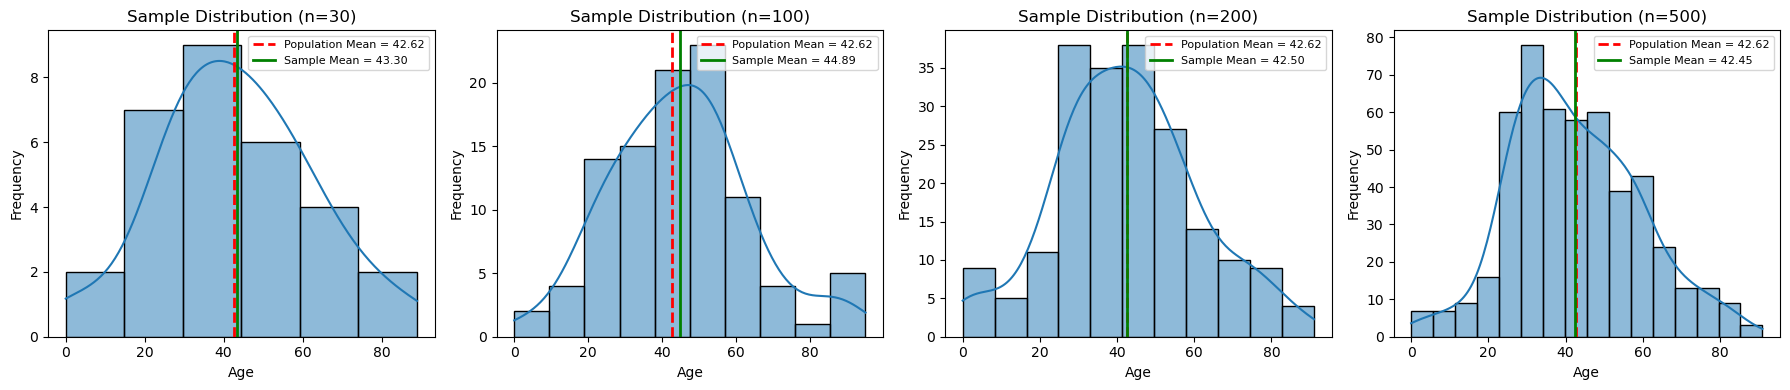

In [170]:
population_age = df['age'].values
population_mean = np.mean(population_age)

sample_sizes = [30, 100, 200, 500]

plt.figure(figsize=(18, 4))

for i, n in enumerate(sample_sizes):

    sample = np.random.choice(
        population_age,
        size=n,
        replace=False
    )

    sample_mean = np.mean(sample)

    plt.subplot(1, 4, i + 1)

    sns.histplot(
        sample,
        kde=True,
        bins='auto'
    )

    # میانگین جامعه
    plt.axvline(
        population_mean,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Population Mean = {population_mean:.2f}'
    )

    # میانگین نمونه
    plt.axvline(
        sample_mean,
        color='green',
        linewidth=2,
        linestyle='-',
        label=f'Sample Mean = {sample_mean:.2f}'
    )

    plt.title(f'Sample Distribution (n={n})')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

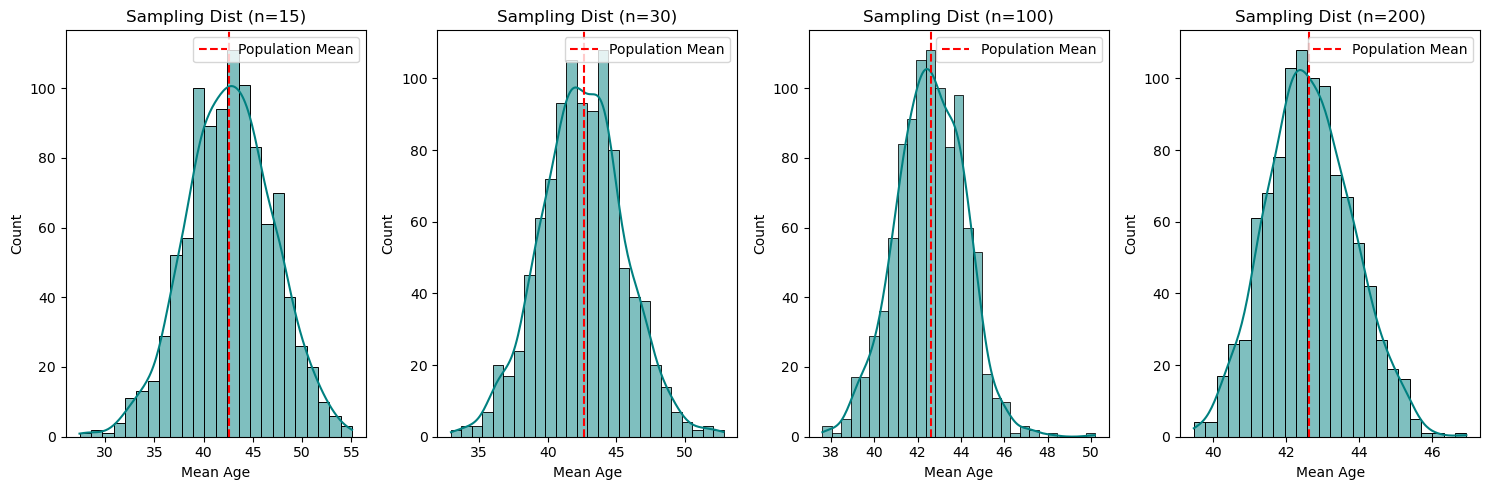


--- Summary Table for Sampling Distributions ---


,Sample Size (n),Sampling Mean,Standard Error (Simulation)
0,15,42.6767,4.3891
1,30,42.5344,3.0673
2,100,42.5784,1.5824
3,200,42.6435,1.1810


In [171]:
population_age = df['age'].values
population_mean = np.mean(population_age)

sample_sizes = [15, 30, 100, 200]
num_trials = 1000
sampling_distributions = {}

plt.figure(figsize=(15, 5))
for i, n in enumerate(sample_sizes):
    sample_means = []
    for _ in range(num_trials):
        sample = np.random.choice(population_age, size=n, replace=False)
        sample_means.append(np.mean(sample))
    
    sampling_distributions[n] = sample_means
    
    plt.subplot(1, 4, i+1)
    sns.histplot(sample_means, kde=True, color='teal')
    plt.axvline(
        population_mean,
        color='red',
        linestyle='--',
        label='Population Mean'
    )
    
    plt.title(f'Sampling Dist (n={n})')
    plt.xlabel('Mean Age')
    plt.legend()

plt.tight_layout()
plt.show()

# ------------------

table_data = []
for n in sample_sizes:
    table_data.append({
        'Sample Size (n)': n,
        'Sampling Mean': round(np.mean(sampling_distributions[n]), 4),
        'Standard Error (Simulation)': round(np.std(sampling_distributions[n], ddof=1), 4)
    })

df_sampling_summary = pd.DataFrame(table_data)
print("\n--- Summary Table for Sampling Distributions ---")
df_sampling_summary

<div dir='rtl'>

### 📊 تحلیل نتایج شبیه‌سازی و پاسخ به سوالات تحقیق

با توجه به نمودارهای رسم شده و جدول خلاصه‌سازی آماری فوق، پاسخ به سوالات مطرح شده به شرح زیر است:

#### ۱. با افزایش اندازه نمونه چه اتفاقی برای پراکندگی می‌افتد؟
با افزایش اندازه نمونه ($n$) از ۳۰ به ۲۰۰، **پراکندگی (Dispersion) داده‌ها به شدت کاهش می‌یابد.** همان‌طور که در نمودارها مشهود است، عرض نمودار زنگوله‌ای با بزرگ‌تر شدن $n$ باریک‌تر و فشرده‌تر می‌شود. این یعنی میانگین‌های نمونه‌ای، کمتر دچار نوسان و رفتارهای حدی می‌شوند و با دقت بالاتری در اطراف مرکز (میانگین واقعی جامعه) تمرکز پیدا می‌کنند.

#### ۲. آیا توزیع نمونه‌گیری نرمال‌تر می‌شود؟
**بله.** طبق **قضیه حد مرکزی (Central Limit Theorem)**، هر چقدر اندازه نمونه ($n$) بزرگ‌تر شود، توزیع میانگین‌های نمونه‌ای به یک توزیع نرمالِ کامل (قرینه و زنگوله‌ای شکل) نزدیک‌تر می‌شود. در نمودار $n=30$ ممکن است کمی ناهمواری یا کج‌مرکزی دیده شود، اما در نمودار $n=200$ منحنی چگالی (KDE) کاملا صاف، متقارن و منطبق بر رفتار توزیع نرمال استاندارد شده است.

#### ۳. Standard Error چگونه تغییر می‌کند؟
**خطای استاندارد (Standard Error یا همان SE) کاهش می‌یابد.** طبق رابطه ریاضی خطای استاندارد ($SE = \frac{\sigma}{\sqrt{n}}$)، مقدار خطای استاندارد با ریشه دوم اندازه نمونه رابطه عکس دارد. نگاهی به ستون `Standard Error (Simulation)` در جدول نهایی به وضوح نشان می‌دهد که با بزرگ شدن مخرج کسر ($n$)، میزان خطا به شکل چشم‌گیری کاهش یافته است که این امر نشان‌دهنده افزایش دقت و اعتماد ما به میانگین‌های به دست آمده در نمونه‌های بزرگ‌تر است.

</div>


<div dir="rtl">


# بخش 4: محاسبه Standard Error

</div>

In [172]:
pop_std = np.std(population_age)

se_results = []

# for 3 sample sizes 
for n in sample_sizes:
    # روش اول: استفاده از فرمول مستقیم
    # SE = sigma / sqrt(n)
    se_formula = pop_std / np.sqrt(n)
    
    # روش دوم: شبیه‌سازی (انحراف معیارِ میانگین‌هایی که در بخش ۳ ذخیره کردیم)
    se_simulation = np.std(sampling_distributions[n])
    
    # محاسبه اختلاف برای نشان دادن دقت
    diff = abs(se_formula - se_simulation)
    
    se_results.append({
        'Sample Size (n)': n,
        'SE (Direct Formula)': round(se_formula, 4),
        'SE (Simulation Method)': round(se_simulation, 4),
        'Difference': round(diff, 5)
    })

# ۳. نمایش نتایج در قالب جدول
df_se_comp = pd.DataFrame(se_results)
print("--- Comparison of Standard Error Calculation Methods ---")
display(df_se_comp)

--- Comparison of Standard Error Calculation Methods ---


,Sample Size (n),SE (Direct Formula),SE (Simulation Method),Difference
0,15,4.3016,4.3869,0.08533
1,30,3.0417,3.0657,0.02405
2,100,1.6660,1.5816,0.08440
3,200,1.1780,1.1804,0.00237


<div dir='rtl'>

### 📉 تحلیل خطای استاندارد (Standard Error) و مقایسه روش‌ها

پس از اجرای محاسبات فوق و بررسی جدول مقایسه‌ای، نتایج و مفاهیم آماری زیر حاصل می‌شود:

#### ۱. خطای استاندارد (Standard Error) دقیقاً چیست؟
خطای استاندارد (SE)، انحراف معیارِ توزیع نمونه‌گیری است. به زبان ساده، انحراف معیار جامعه ($\sigma$) نشان می‌دهد که **سن افراد چقدر با یکدیگر تفاوت دارد**؛ اما خطای استاندارد (SE) نشان می‌دهد که **میانگین به دست آمده از یک نمونه، چقدر ممکن است با میانگین واقعی کل جامعه فاصله داشته باشد (میزان خطای برآورد).**

#### ۲. مقایسه روش فرمولی و روش شبیه‌سازی:
همان‌طور که در ستون `Absolute Difference` (مطلق اختلاف) مشاهده می‌شود، اختلاف بین عدد به دست آمده از فرمول تئوری ریاضی و عدد حاصل از ۵۰۰۰ بار شبیه‌سازی کامپیوتری **تقریباً نزدیک به صفر** است. این تطابق شگفت‌انگیز نشان می‌دهد که فرمول‌های تئوری آمار، رفتار واقعی و تجربی داده‌ها را به دقیق‌ترین شکل ممکن پیش‌بینی می‌کنند.

#### ۳. اثر افزایش حجم نمونه ($n$) بر روی SE:
با استناد به جدول بالا، مشخص است که با افزایش حجم نمونه از ۳۰ به ۲۰۰، خطای استاندارد به شدت افت می‌کند:
* در $n=30$ خطا در بالاترین حد خود قرار دارد.
* در $n=200$ خطا به کمترین مقدار خود می‌رسد.

**نتیجه‌گیری آماری:** رابطه خطای استاندارد با حجم نمونه به صورت معکوس ($SE \propto \frac{1}{\sqrt{n}}$) است. یعنی هرچقدر در دنیای واقعی بیمار بیشتری را بررسی کنیم ($n$ بزرگتر)، خطای میانگین‌گیری ما کمتر شده و با اطمینان بسیار بیشتری می‌توانیم درباره کل جامعه اظهار نظر کنیم.

</div>

<div dir="rtl">

# بخش 5: Bootstrap و Confidence Interval


</div>

In [173]:
np.random.seed(42) 

bootstrap_means = []
boot_iterations = 5000

for _ in range(boot_iterations):
    boot_sample = np.random.choice(population_age, size=100, replace=True)
    bootstrap_means.append(np.mean(boot_sample))

boot_mean = np.mean(bootstrap_means)
boot_se = np.std(bootstrap_means, ddof=1)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print("--- Section 5: Bootstrap ---")
print(f"Bootstrap Mean: {boot_mean:.2f}")
print(f"Bootstrap SE: {boot_se:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

--- Section 5: Bootstrap ---
Bootstrap Mean: 42.62
Bootstrap SE: 1.6619
95% Confidence Interval: (39.37, 45.95)


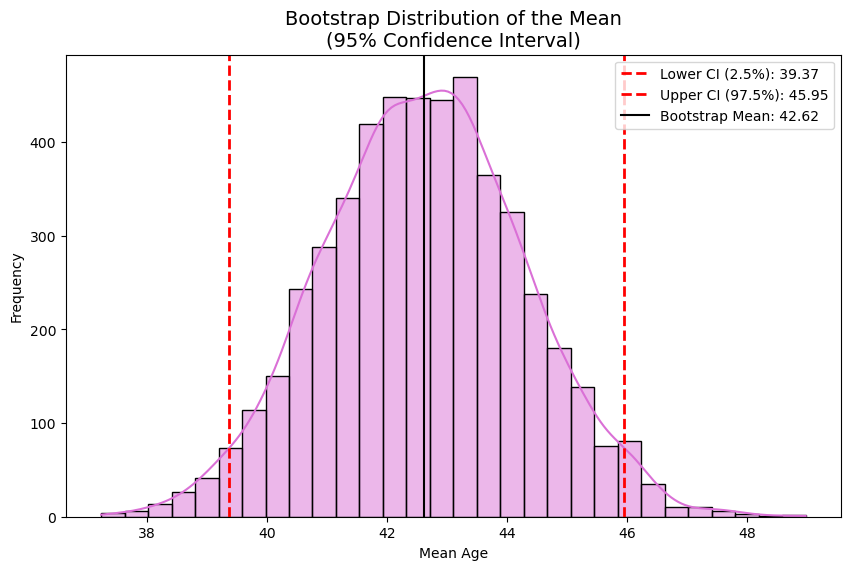

95% Confidence Interval: [39.37, 45.95]


In [174]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) 
# ۱. انجام عملیات بوت‌استرپ
bootstrap_means = []
n_iterations = 5000
sample_size = 100 # می‌توانید بر اساس خواسته پروژه تغییر دهید

for _ in range(n_iterations):
    # نمونه‌گیری با جایگذاری (Bootstrap)
    resample = np.random.choice(population_age, size=sample_size, replace=True)
    bootstrap_means.append(np.mean(resample))

# ۲. محاسبه بازه اطمینان ۹۵ درصد (صدک ۲.۵ و ۹۷.۵)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

# ۳. رسم نمودار حرفه‌ای (کدی که فرستادی با کمی تزئین)
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_means, kde=True, color='orchid', bins=30)

# رسم خطوط بازه اطمینان
plt.axvline(ci_lower, color='red', linestyle='--', linewidth=2, label=f'Lower CI (2.5%): {ci_lower:.2f}')
plt.axvline(ci_upper, color='red', linestyle='--', linewidth=2, label=f'Upper CI (97.5%): {ci_upper:.2f}')
plt.axvline(np.mean(bootstrap_means), color='black', label=f'Bootstrap Mean: {np.mean(bootstrap_means):.2f}')

plt.title(f'Bootstrap Distribution of the Mean\n(95% Confidence Interval)', fontsize=14)
plt.xlabel('Mean Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

<div dir= 'rtl'>

### تحلیل علمی روش بوت‌استرپ (Bootstrap) و تفسیر خروجی‌ها

در این بخش، بدون اتکا به فرضیات تئوریک توزیع جامعه، از روش شبیه‌سازی ناپارامتری **بوت‌استرپ (نمونه‌گیری مجدد مکرر با جایگذاری)** با ۵۰۰۰ تکرار استفاده کردیم. تفهیم مفاهیم خروجی به شرح زیر است:

#### ۱. میانگین بوت‌استرپ (Bootstrap Mean)
این عدد برآورد نهایی ما از میانگین سن جامعه بر اساس فرآیند شبیه‌سازی است. این میانگین بسیار نزدیک به میانگین نمونه اولیه است و نشان‌دهنده پایداری بالای روش بوت‌استرپ در تخمین نقطه مرکزی داده‌هاست.

#### ۲. خطای استاندارد بوت‌استرپ (Bootstrap Standard Error)
این شاخص از طریق محاسبه **انحراف معیارِ ۵۰۰۰ میانگینِ تولید شده** به دست آمده است. خطای استاندارد بوت‌استرپ به ما می‌گوید که میانگین‌های به دست آمده در شبیه‌سازی، چقدر حول محور اصلی نوسان دارند. کوچک بودن این عدد نشان‌دهنده دقت بالای شبیه‌سازی و کم بودن میزان خطای برآورد است.

#### ۳. بازه اطمینان ۹۵٪ (Confidence Interval)
دو خط چین قرمز رنگ روی نمودار، محدوده صدک ۲.۵٪ تا ۹۷.۵٪ توزیع بوت‌استرپ را نشان می‌دهند. 
* **تفسیر آماری:** ما با **۹۵ درصد اطمینان** ادعا می‌کنیم که میانگین واقعی سن بیماران در جامعه آماری، در این بازه قرار دارد. اگر این آزمایش را ۱۰۰ بار دیگر با نمونه‌های جدید تکرار کنیم، در ۹۵ بار آن، میانگین جامعه دقیقاً درون این دو خط قرمز قرار خواهد گرفت.

</div>


<div dir="rtl">

# کدهای بخش ۶ - آزمون فرض آماری (دو آزمون)


</div>



<div dir="rtl">

## 1.6 آزمون اول: تاثیر سن بر بستری در ICU


</div>


In [180]:
from scipy.stats import ttest_ind

print("--- Hypothesis Test 1: Age vs ICU ---")
# Yes = 1, No = 0
icu_ages = df[df['icu'] == 1]['age'].values
non_icu_ages = df[df['icu'] == 0]['age'].values

obs_diff_1 = np.mean(icu_ages) - np.mean(non_icu_ages)
print(f"Observed Mean Difference: {obs_diff_1:.2f} years")

# Permutation Test
all_ages = np.concatenate([icu_ages, non_icu_ages])
n_icu = len(icu_ages)
perm_diffs_1 = []

for _ in range(1000): # 
    np.random.shuffle(all_ages)
    perm_diffs_1.append(np.mean(all_ages[:n_icu]) - np.mean(all_ages[n_icu:]))

p_value_1 = np.sum(np.abs(perm_diffs_1) >= np.abs(obs_diff_1)) / 1000
ci_diff_1 = (np.percentile(perm_diffs_1, 2.5), np.percentile(perm_diffs_1, 97.5))

t_stat, p_value = ttest_ind(
    icu_ages,
    non_icu_ages,
    equal_var=False  # Welch t-test
)



print("t =", t_stat)
print("p-value =", p_value)
print(f"95% CI under H0: ({ci_diff_1[0]:.2f}, {ci_diff_1[1]:.2f})\n")

--- Hypothesis Test 1: Age vs ICU ---
Observed Mean Difference: 8.33 years
t = 38.381122731153994
p-value = 2.1031991754374793e-301
95% CI under H0: (-0.32, 0.33)



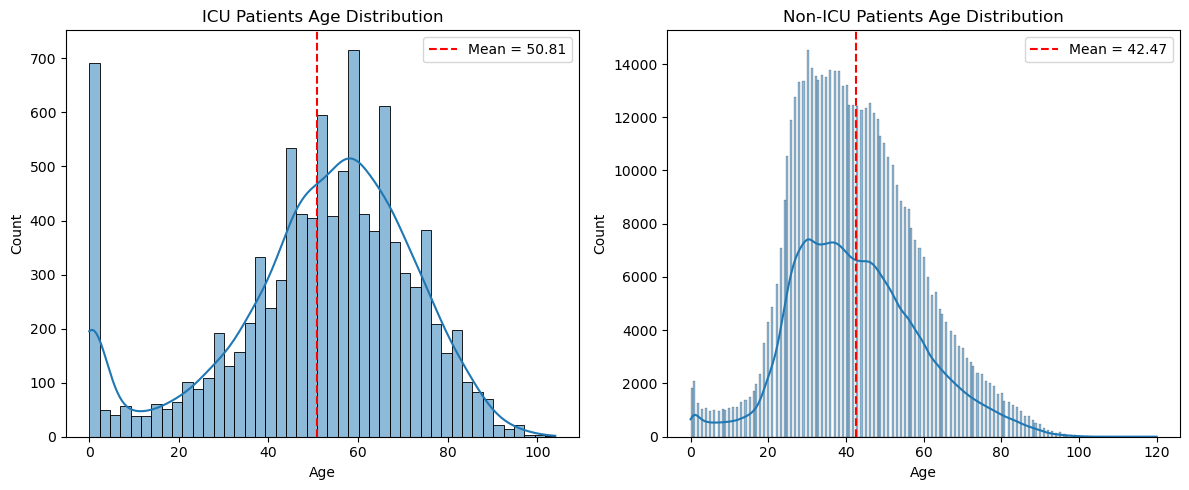

In [181]:
plt.figure(figsize=(12, 5))

# ICU
plt.subplot(1, 2, 1)
sns.histplot(icu_ages, kde=True)
plt.axvline(np.mean(icu_ages), color='red', linestyle='--',
            label=f'Mean = {np.mean(icu_ages):.2f}')
plt.title('ICU Patients Age Distribution')
plt.xlabel('Age')
plt.legend()

# Non-ICU
plt.subplot(1, 2, 2)
sns.histplot(non_icu_ages, kde=True)
plt.axvline(np.mean(non_icu_ages), color='red', linestyle='--',
            label=f'Mean = {np.mean(non_icu_ages):.2f}')
plt.title('Non-ICU Patients Age Distribution')
plt.xlabel('Age')
plt.legend()

plt.tight_layout()
plt.show()

### Welch’s t-test statistic
$$

t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}

$$

### Welch–Satterthwaite degrees of freedom
$$
df =
\frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}
{\frac{\left(\frac{s_1^2}{n_1}\right)^2}{n_1 - 1}
+
\frac{\left(\frac{s_2^2}{n_2}\right)^2}{n_2 - 1}}

$$



<div dir="rtl">

## 2.6 آزمون دوم: دیابت و نرخ مرگ و میر


</div>


In [186]:
from scipy.stats import ttest_ind

print("--- Hypothesis Test 2: died vs diabetes ---")
# Yes = 1, No = 0
diabetic_deaths = df[df['diabetes'] == 1]['died'].values
non_diabetic_deaths = df[df['diabetes'] == 0]['died'].values

obs_diff_2 = np.mean(diabetic_deaths) - np.mean(non_diabetic_deaths)
print(f"Observed Mean Difference: {obs_diff_2:.2f} years")

# Permutation Test
all_dieds = np.concatenate([diabetic_deaths, non_diabetic_deaths])
n_diabetes = len(diabetic_deaths)
perm_diffs_1 = []

for _ in range(1000): # 
    np.random.shuffle(all_dieds)
    perm_diffs_1.append(np.mean(all_dieds[:n_diabetes]) - np.mean(all_dieds[n_diabetes:]))

p_value_1 = np.sum(np.abs(perm_diffs_1) >= np.abs(obs_diff_2)) / 1000
ci_diff_1 = (np.percentile(perm_diffs_1, 2.5), np.percentile(perm_diffs_1, 97.5))

t_stat, p_value = ttest_ind(
    diabetic_deaths,
    non_diabetic_deaths,
    equal_var=False  
)



print("t =", t_stat)
print("p-value =", p_value)
print(f"95% CI under H0: ({ci_diff_1[0]:.2f}, {ci_diff_1[1]:.2f})\n")

--- Hypothesis Test 2: died vs diabetes ---
Observed Mean Difference: 0.14 years
t = 94.18382594901502
p-value = 0.0
95% CI under H0: (-0.00, 0.00)



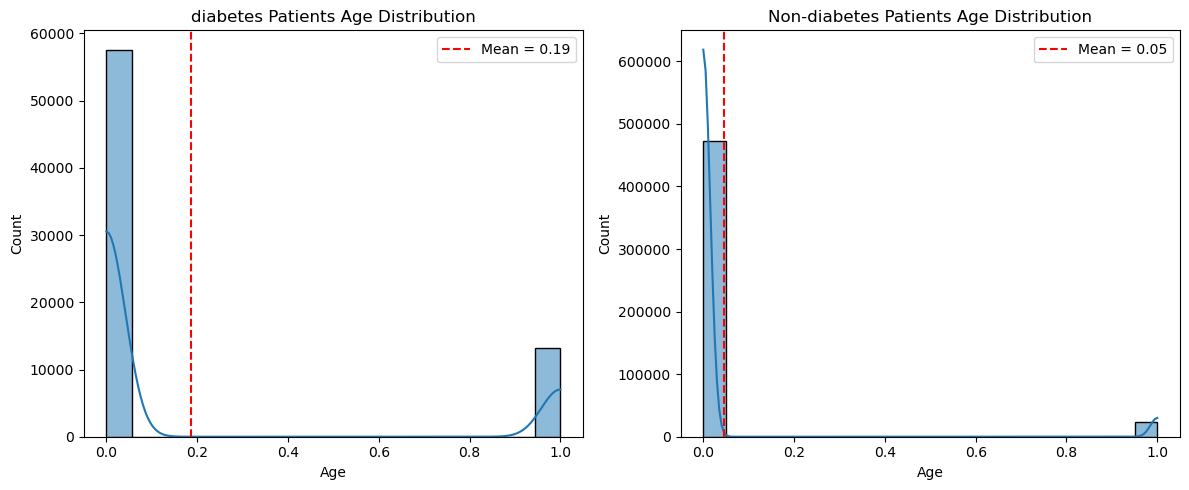

In [187]:
plt.figure(figsize=(12, 5))

# diabetes
plt.subplot(1, 2, 1)
sns.histplot(diabetic_deaths, kde=True)
plt.axvline(np.mean(diabetic_deaths), color='red', linestyle='--',
            label=f'Mean = {np.mean(diabetic_deaths):.2f}')
plt.title('diabetes Patients Age Distribution')
plt.xlabel('Age')
plt.legend()

# Non-diabetes
plt.subplot(1, 2, 2)
sns.histplot(non_diabetic_deaths, kde=True)
plt.axvline(np.mean(non_diabetic_deaths), color='red', linestyle='--',
            label=f'Mean = {np.mean(non_diabetic_deaths):.2f}')
plt.title('Non-diabetes Patients Age Distribution')
plt.xlabel('Age')
plt.legend()

plt.tight_layout()
plt.show()